# Tugas 1 - Modul K-Means Clustering GPS Trajectories

**Nama          :** Sarah Nurul Yakin  
**Mata Kuliah   :** Machine Learning  
**Materi        :** K-Means Clustering  

---

## Deskripsi Tugas

Project ini merupakan implementasi algoritma K-Means Clustering menggunakan dataset GPS Trajectories dari UCI Machine Learning Repository. 

Tujuan dari project ini adalah untuk mengelompokkan data perjalanan berdasarkan karakteristik tertentu seperti distance dan speed menggunakan metode clustering.

Dataset diproses menggunakan Python dan divisualisasikan untuk melihat hasil pengelompokan data.


### Membuat model dengan K-Means Clustering

In [1]:
# import library 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler


In [4]:
# load data 
baca = pd.read_csv("../dataset/go_track_tracks.csv")
baca.head()


,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus,linha
0,1,0,19.210586,0.138049,2.652,3,0,0,1,NaN
1,2,0,30.848229,0.171485,5.290,3,0,0,1,NaN
2,3,1,13.560101,0.067699,0.918,3,0,0,2,NaN
3,4,1,19.766679,0.389544,7.700,3,0,0,2,NaN
4,8,0,25.807401,0.154801,3.995,2,0,0,1,NaN


In [5]:
# informasi dataset
baca.info

<bound method DataFrame.info of         id  id_android      speed      time  distance  rating  rating_bus  \
0        1           0  19.210586  0.138049     2.652       3           0   
1        2           0  30.848229  0.171485     5.290       3           0   
2        3           1  13.560101  0.067699     0.918       3           0   
3        4           1  19.766679  0.389544     7.700       3           0   
4        8           0  25.807401  0.154801     3.995       2           0   
..     ...         ...        ...       ...       ...     ...         ...   
158  38081          24  30.051732  0.218756     6.574       2           0   
159  38082          24  30.173788  0.255387     7.706       3           0   
160  38084          25   1.153772  0.013001     0.015       1           3   
161  38090          26   0.843223  0.007116     0.006       3           1   
162  38092          27   1.372998  0.016752     0.023       3           1   

     rating_weather  car_or_bus            

In [6]:
# Menghapus kolom 'linha'
baca = baca.drop(["linha"], axis=1)

baca.head()

,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus
0,1,0,19.210586,0.138049,2.652,3,0,0,1
1,2,0,30.848229,0.171485,5.290,3,0,0,1
2,3,1,13.560101,0.067699,0.918,3,0,0,2
3,4,1,19.766679,0.389544,7.700,3,0,0,2
4,8,0,25.807401,0.154801,3.995,2,0,0,1


In [7]:
# Menentukan variabel yang akan di klusterkan
baca_x = baca.iloc[:, 1:3]
baca_x.head()



,id_android,speed
0,0,19.210586
1,0,30.848229
2,1,13.560101
3,1,19.766679
4,0,25.807401


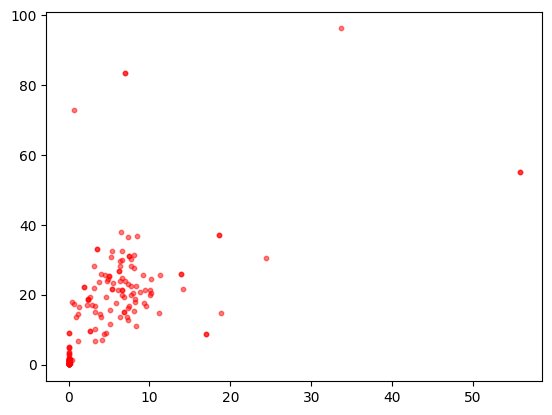

In [8]:
# Memvisualkan persebaran data
plt.scatter(baca.distance, baca.speed, s =10, c = "red", marker = "o", alpha = 0.5)
plt.show()




In [9]:
# Mengubah data dari dataframe menjadi array
x_array = np.array(baca_x)

# Menampilkan isi array
print(x_array)

[[0.00000000e+00 1.92105856e+01]
 [0.00000000e+00 3.08482291e+01]
 [1.00000000e+00 1.35601009e+01]
 [1.00000000e+00 1.97666790e+01]
 [0.00000000e+00 2.58074009e+01]
 [2.00000000e+00 1.34691332e+00]
 [3.00000000e+00 3.68507874e+01]
 [1.00000000e+00 1.74051313e+01]
 [1.00000000e+00 1.53954361e+01]
 [1.00000000e+00 8.90272944e+00]
 [3.00000000e+00 1.50413480e+01]
 [3.00000000e+00 1.44400981e+01]
 [1.00000000e+00 1.63567325e+01]
 [1.00000000e+00 1.75427999e+01]
 [4.00000000e+00 9.45181557e+00]
 [4.00000000e+00 9.45181557e+00]
 [4.00000000e+00 1.62635039e+01]
 [4.00000000e+00 2.12235944e+01]
 [4.00000000e+00 1.94236545e+01]
 [4.00000000e+00 2.07996291e+01]
 [4.00000000e+00 8.72437242e+00]
 [4.00000000e+00 8.72437242e+00]
 [3.00000000e+00 8.68613764e+00]
 [3.00000000e+00 5.49959473e+01]
 [3.00000000e+00 5.49959473e+01]
 [1.00000000e+00 1.26110448e+01]
 [3.00000000e+00 1.45342872e+01]
 [3.00000000e+00 1.02882267e+01]
 [3.00000000e+00 1.83281891e+01]
 [1.00000000e+00 1.71776350e+01]
 [1.000000

In [10]:
# Normalisasi data dengan metode Min-Max Scaling
scaler = MinMaxScaler()

x_scaled = scaler.fit_transform(x_array)

x_scaled

array([[0.00000000e+00, 1.99600362e-01],
       [0.00000000e+00, 3.20578504e-01],
       [3.70370370e-02, 1.40861225e-01],
       [3.70370370e-02, 2.05381184e-01],
       [0.00000000e+00, 2.68176999e-01],
       [7.40740741e-02, 1.39000630e-02],
       [1.11111111e-01, 3.82977592e-01],
       [3.70370370e-02, 1.80831914e-01],
       [3.70370370e-02, 1.59940297e-01],
       [3.70370370e-02, 9.24459124e-02],
       [1.11111111e-01, 1.56259404e-01],
       [1.11111111e-01, 1.50009162e-01],
       [3.70370370e-02, 1.69933373e-01],
       [3.70370370e-02, 1.82263037e-01],
       [1.48148148e-01, 9.81538910e-02],
       [1.48148148e-01, 9.81538910e-02],
       [1.48148148e-01, 1.68964223e-01],
       [1.48148148e-01, 2.20526426e-01],
       [1.48148148e-01, 2.01815302e-01],
       [1.48148148e-01, 2.16119130e-01],
       [1.48148148e-01, 9.05918170e-02],
       [1.48148148e-01, 9.05918170e-02],
       [1.11111111e-01, 9.01943506e-02],
       [1.11111111e-01, 5.71604072e-01],
       [1.111111

### Membuat Model Klasifikasi 

In [11]:
from sklearn.cluster import KMeans


In [12]:
# Membuat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)


In [13]:
# Training model
kmeans.fit(baca)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [14]:
# Menampilkan label cluster
print(kmeans.labels_)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [15]:
# Menambahkan hasil cluster ke dataframe
baca["kluster"] = kmeans.labels_


In [16]:
# Menampilkan data
print(baca.head())


   id  id_android      speed      time  distance  rating  rating_bus  \
0   1           0  19.210586  0.138049     2.652       3           0   
1   2           0  30.848229  0.171485     5.290       3           0   
2   3           1  13.560101  0.067699     0.918       3           0   
3   4           1  19.766679  0.389544     7.700       3           0   
4   8           0  25.807401  0.154801     3.995       2           0   

   rating_weather  car_or_bus  kluster  
0               0           1        0  
1               0           1        0  
2               0           2        0  
3               0           2        0  
4               0           1        0  


### Membuat Report Hasil Klasifikasi


In [20]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Mengambil label hasil clustering
y_pred = kmeans.labels_

# Menggunakan label cluster sebagai pembanding
y_test = y_pred

In [22]:
# Accuracy
accuracy_score(y_test, y_pred)

# Classification report
print(f'Classification Report: \n{classification_report(y_test, y_pred)}')

# F1 score
print(f"F1 Score : {f1_score(y_test, y_pred, average='macro')}")

Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00        65
           2       1.00      1.00      1.00         2

    accuracy                           1.00       163
   macro avg       1.00      1.00      1.00       163
weighted avg       1.00      1.00      1.00       163

F1 Score : 1.0


In [23]:
# Menampilkan label cluster
print(kmeans.labels_)

# Menambahkan hasil cluster ke dataframe
baca["kluster"] = kmeans.labels_

# Menampilkan data
print(baca.head())

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
   id  id_android      speed      time  distance  rating  rating_bus  \
0   1           0  19.210586  0.138049     2.652       3           0   
1   2           0  30.848229  0.171485     5.290       3           0   
2   3           1  13.560101  0.067699     0.918       3           0   
3   4           1  19.766679  0.389544     7.700       3           0   
4   8           0  25.807401  0.154801     3.995       2           0   

   rating_weather  car_or_bus  kluster  
0               0           1        0  
1               0           1        0  
2               0           2        0  
3               0           2        0  
4               0           1 

### Visualisasi Hasil Clustering

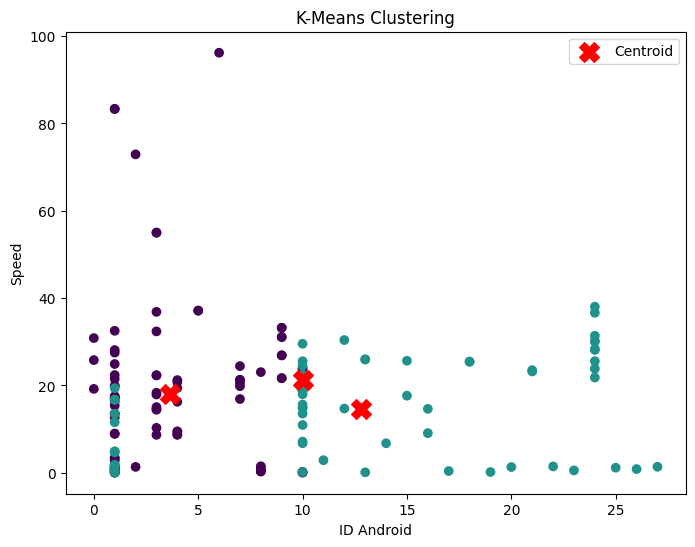

In [28]:
import matplotlib.pyplot as plt

# Membuat ukuran grafik
plt.figure(figsize=(8,6))

# Menampilkan hasil clustering
plt.scatter(
    baca['id_android'],
    baca['speed'],
    c=baca['kluster'],
    cmap='viridis'
)

# Menampilkan titik centroid
plt.scatter(
    kmeans.cluster_centers_[:, 1],
    kmeans.cluster_centers_[:, 2],
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

# Memberikan label pada sumbu
plt.xlabel('ID Android')
plt.ylabel('Speed')

# Memberikan judul grafik
plt.title('K-Means Clustering')

# Menampilkan legenda
plt.legend()

# Menyimpan visualisasi clustering
plt.savefig("../hasil/visualisasi_cluster_gps.png")

# Menampilkan grafik
plt.show()

### Menyimpan Hasil Clustering ke CSV

In [25]:
# Menyimpan hasil clustering ke file CSV
baca.to_csv("../hasil/hasil_cluster_gps.csv", index=False)

print("Hasil clustering berhasil disimpan.")

Hasil clustering berhasil disimpan.


In [27]:
# Menyimpan hasil visualisasi 
# Menyimpan visualisasi clustering
plt.savefig("../hasil/visualisasi_cluster_gps.png")

# Menampilkan grafik
plt.show()

<Figure size 640x480 with 0 Axes>

In [26]:
# Membuat ringkasan cluster
ringkasan_cluster = baca.groupby("kluster")[["distance", "speed"]].mean()

# Menampilkan ringkasan cluster
print(ringkasan_cluster)

# Menyimpan ringkasan cluster ke CSV
ringkasan_cluster.to_csv("../hasil/ringkasan_cluster_gps.csv")

print("Ringkasan cluster berhasil disimpan.")

         distance      speed
kluster                     
0        5.585031  17.992407
1        4.845477  14.664773
2        6.587000  21.195493
Ringkasan cluster berhasil disimpan.


### Kesimpulan

Berdasarkan percobaan yang telah dilakukan, algoritma K-Means Clustering berhasil diterapkan pada dataset GPS Trajectories.

Data perjalanan berhasil dikelompokkan ke dalam beberapa cluster berdasarkan karakteristik tertentu seperti distance dan speed.

Hasil clustering dapat divisualisasikan menggunakan scatter plot sehingga persebaran data dan centroid setiap cluster dapat terlihat dengan jelas.